# **AI_02_Water_Intake_Predictor**

## **Data Preprocessing**

### **01. Installing PyTorch with GPU (CUDA) Support**

In [1]:
!pip3 install torch torchvision --extra--index-url https://download.pytorch.org/whl/cu126


[optparse.groups]Usage:[/]   
  pip3 install \[options] <requirement specifier> \[package-index-options] ...
  pip3 install \[options] -r <requirements file> \[package-index-options] ...
  pip3 install \[options] [-e] <vcs project url> ...
  pip3 install \[options] [-e] <local project path> ...
  pip3 install \[options] <archive url/path> ...

no such option: --extra--index-url


In [2]:
import torch
print(torch.cuda.is_available())        # should be True
print(torch.cuda.device_count())        # should be 1
print(torch.cuda.get_device_name(0))    # should show your RTX 5060

True
1
NVIDIA GeForce RTX 5060 Laptop GPU


d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv\lib\site-packages\torch\cuda\__init__.py:384: UserWarning: Found GPU0 NVIDIA GeForce RTX 5060 Laptop GPU which is of compute capability (CC) 12.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 5.0 which supports hardware CC >=5.0,<6.0 except {5.3}
- 6.0 which supports hardware CC >=6.0,<7.0 except {6.2}
- 6.1 which supports hardware CC >=6.1,<7.0 except {6.2}
- 7.0 which supports hardware CC >=7.0,<8.0 except {7.2}
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 13.0, 13.2
  _warn_unsupported_code(d, device_cc, code_ccs)
d:\My_Projects\Project_02_GYM_Mobile_App\AI_Models\venv

### **02. Import the Python Libraries**

##### **Core Libraries**
* *Pandas* - Used to load, organize, clean, and analyze data in tables (DataFrames).
* *NumPy* - Used for fast mathematical calculations and handling missing values.
* *Seaborn* - Used to create attractive statistical charts and graphs.
* *Matplotlib* - Used to create and customize charts, graphs, and plots.

##### Setup Commands
* *%matplotlib inline* - Shows graphs directly inside a Jupyter Notebook
* *sns.set(color_codes=True)* - Applies a better chart style and uses cleaner colors automatically.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
from sklearn.preprocessing import MinMaxScaler

### **03. Load the dataset**

In [4]:
df = pd.read_csv("../datasets/Water_Intake_Data_Set.csv")

### **04. Display the first and the last 5 rows of the data**

In [5]:
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good
29999,26,Female,98,4.43,Moderate,Hot,Good


### **05. Check for the Types of the Data in the Dataset**

In [6]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
Age                              int64
Gender                          object
Weight (kg)                      int64
Daily Water Intake (liters)    float64
Physical Activity Level         object
Weather                         object
Hydration Level                 object
dtype: object


### **06. Remove all rows where the Hydration Level is "Poor".**


In [7]:
df = df.drop(df[df['Hydration Level'] == 'Poor'].index, axis=0)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
5,39,Female,93,2.81,Low,Normal,Good



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
29994,44,Male,108,3.40,Low,Cold,Good
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29998,36,Male,106,4.00,Low,Hot,Good
29999,26,Female,98,4.43,Moderate,Hot,Good


### **07. Remove the irrelevant columns**

In [8]:
df = df.drop(["Hydration Level"], axis=1)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather
0,56,Male,96,4.23,Moderate,Hot
1,60,Male,105,3.95,High,Normal
2,36,Male,68,2.39,Moderate,Cold
3,19,Female,74,3.13,Moderate,Hot
5,39,Female,93,2.81,Low,Normal



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather
29994,44,Male,108,3.40,Low,Cold
29995,47,Male,97,3.45,Moderate,Cold
29996,49,Female,109,5.32,High,Hot
29998,36,Male,106,4.00,Low,Hot
29999,26,Female,98,4.43,Moderate,Hot


### **08. Check for Duplicate Rows**

In [9]:
rows = df.shape[0]     
columns = df.shape[1]  

print(f"Number of rows = {rows}")
print(f"Number of columns = {columns}")

Number of rows = 23915
Number of columns = 6


In [10]:
df.count()

Age                            23915
Gender                         23915
Weight (kg)                    23915
Daily Water Intake (liters)    23915
Physical Activity Level        23915
Weather                        23915
dtype: int64

In [11]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicates rows: ", duplicate_rows_df.shape)

# (duplicates rows, Columns)

Number of duplicates rows:  (185, 6)


In [12]:
# Drop Duplicate Rows

df = df.drop_duplicates()

duplicate_rows_df = df[df.duplicated()]
print("Number of duplicates rows: ", duplicate_rows_df.shape)

Number of duplicates rows:  (0, 6)


### **09. Check missing or Null Values**

In [13]:
print(df.isnull().sum())

Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
dtype: int64


### **10. Remove Outliers using IQR Method**
* **Seven-Iteration Filtering:** The IQR (Interquartile Range) filter is applied seven times to remove all outliers more effectively from the numerical data.

Total rows before removing outliers: 23730


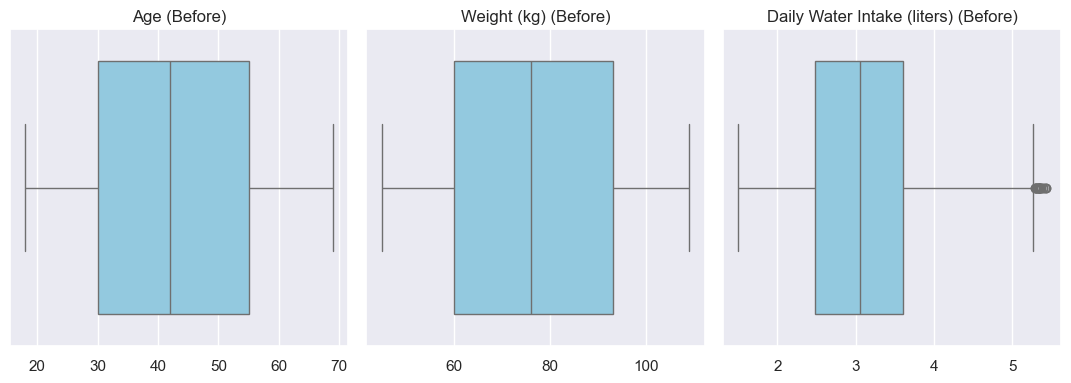

Total rows after removing outliers (Cleaned): 23707


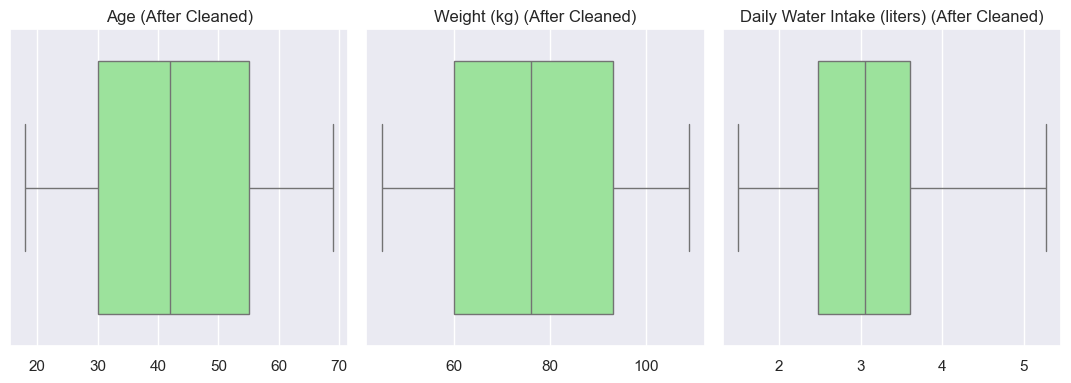

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. List of numerical columns to check for outliers
num_cols = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]

print(f"Total rows before removing outliers: {df.shape[0]}")

# 2. Visualize Box Plots BEFORE removing outliers
plt.figure(figsize=(18, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"{col} (Before)")
    plt.xlabel("")
plt.tight_layout()
plt.show()

# 3. Run the IQR filter ONE TIMES (1 Iterations) to clean remaining outliers
for iteration in range(1):
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Total rows after removing outliers (Cleaned): {df.shape[0]}")

# 4. Visualize Box Plots AFTER removing outliers again
plt.figure(figsize=(18, 4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"{col} (After Cleaned)")
    plt.xlabel("")
plt.tight_layout()
plt.show()

### **11. Label Encode Catogorical Data**

In [15]:
df["Physical Activity Level"] = df["Physical Activity Level"].map({"Low": 0, "Moderate": 1, "High": 2})

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather
0,56,Male,96,4.23,1,Hot
1,60,Male,105,3.95,2,Normal
2,36,Male,68,2.39,1,Cold
3,19,Female,74,3.13,1,Hot
5,39,Female,93,2.81,0,Normal



--- Last 5 Rows ---


,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather
29993,42,Male,76,2.75,1,Normal
29994,44,Male,108,3.40,0,Cold
29995,47,Male,97,3.45,1,Cold
29998,36,Male,106,4.00,0,Hot
29999,26,Female,98,4.43,1,Hot


### **12. One-Hot Encoding Encode Catogorical Data**

In [16]:
df = pd.get_dummies(df, columns=["Gender", "Weather"], drop_first=True, dtype=int)

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())

--- First 5 Rows ---


,Age,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Gender_Male,Weather_Hot,Weather_Normal
0,56,96,4.23,1,1,1,0
1,60,105,3.95,2,1,0,1
2,36,68,2.39,1,1,0,0
3,19,74,3.13,1,0,1,0
5,39,93,2.81,0,0,0,1



--- Last 5 Rows ---


,Age,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Gender_Male,Weather_Hot,Weather_Normal
29993,42,76,2.75,1,1,0,1
29994,44,108,3.40,0,1,0,0
29995,47,97,3.45,1,1,0,0
29998,36,106,4.00,0,1,1,0
29999,26,98,4.43,1,0,1,0


## **Tarin Model**

### **13. Split the dataset into Features (X) and Target (y)**

In [17]:
# Inputs (Features)
X = df[['Age', 'Weight (kg)', 'Physical Activity Level', 'Gender_Male', 'Weather_Hot', 'Weather_Normal']]

# Output (Target)
y = df['Daily Water Intake (liters)']

### **14. Split the data into Training and Testing sets (Train-Test Split).**

In [18]:
from sklearn.model_selection import train_test_split

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 18965, Testing samples: 4742


### **15. Train and evaluate the Random Forest Regression model.**

### ***Random Forest Regression***

##### **Mean Squared Error (MSE)**
* *Low value* → Good model, predictions are close to actual values.
* *High value* → Poor model, predictions are far from actual values.

##### **Root Mean Squared Error (RMSE)**
* *Low value* → Good model, small prediction errors.
* *High value* → Poor model, large prediction errors.

##### **R² Score (Accuracy)**
* *Close to 1.00* → Excellent model performance.
* *Around 0.50* → Moderate model performance
* *Close to 0.00 or negative* → Poor model performance.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Create the model.
model = RandomForestRegressor(
    n_estimators=200,      # Increased the number of trees to 200
    max_depth=8,           # Set the maximum tree depth to 8 to prevent overfitting
    min_samples_split=5, 
    min_samples_leaf=4,
    random_state=42
)

# 2. Train (fit) the model using the training data.
model.fit(X_train, y_train)

# 3. Use the test data to make predictions.
y_pred = model.predict(X_test)

# 4. Evaluate the model's performance.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Accuracy): {r2:.2f}") 

Mean Squared Error (MSE): 0.07
Root Mean Squared Error (RMSE): 0.27
R² Score (Accuracy): 0.89


### **16. Model Evaluation and Visualization**

##### **Graph 1: Actual vs. Predicted Water Intake**

* **Purpose:** Compares actual values with predicted values.
* **Blue Dots:** Show the model's predictions and actual values.
* **Red Dashed Line:** Represents perfect predictions.
* **Interpretation:** Dots closer to the red line mean the model is more accurate.

##### **Graph 2: Feature Importance**

* **Purpose:** Shows which features have the biggest effect on water intake prediction.
* **Bars:** Longer bars indicate more important features.
* **Interpretation:** Helps identify the most influential features and shows that the model makes logical predictions.


C:\Users\Manuka Abeysekara\AppData\Local\Temp\ipykernel_25604\763802189.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[1], palette="viridis")


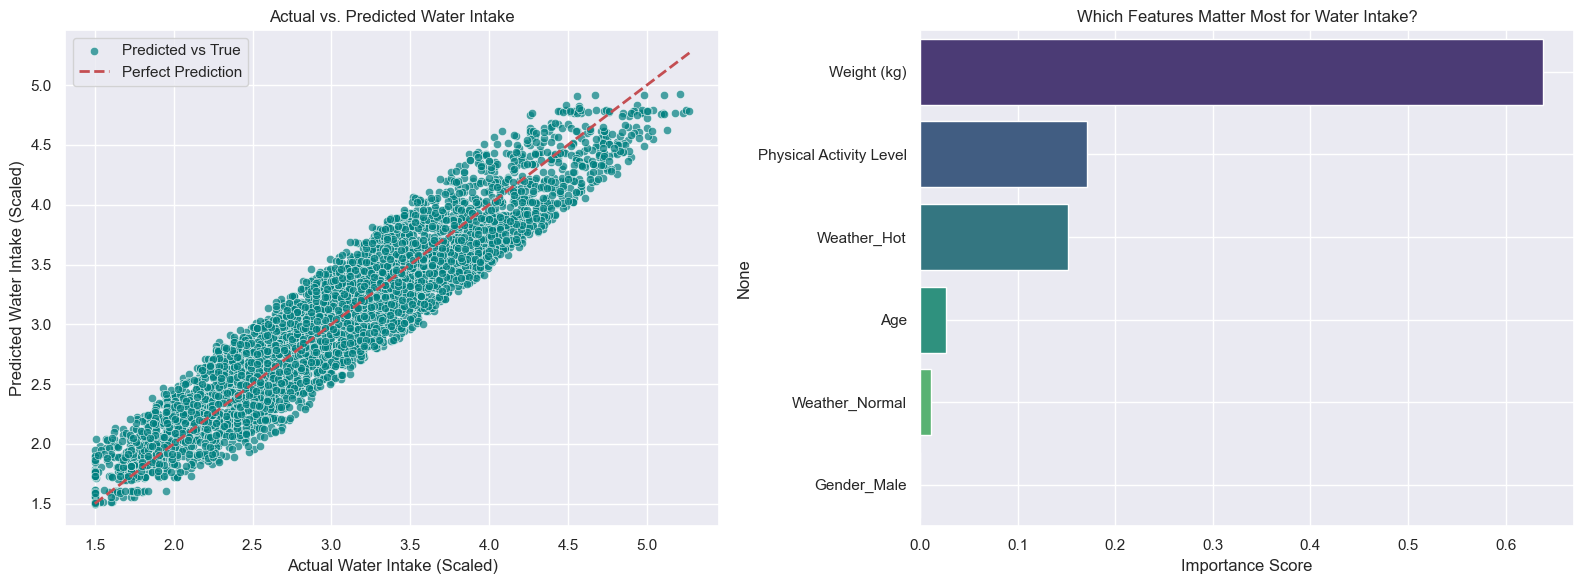

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual vs. Predicted Water Intake 
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color="teal", alpha=0.7, label="Predicted vs True")

# Perfect Prediction Line එක
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Water Intake (Scaled)")
axes[0].set_ylabel("Predicted Water Intake (Scaled)")
axes[0].set_title("Actual vs. Predicted Water Intake")
axes[0].legend()
axes[0].grid(True)

# Graph 2: Random Forest Feature Importance (Finding the Most Important Features)
# Get the feature importance values from the trained model
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame and sort features from highest importance to lowest importance
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Draw a bar plot
sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[1], palette="viridis")
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Which Features Matter Most for Water Intake?")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### **17. Test the traine model by giving sample value.**

In [21]:
import pandas as pd

# 1. Provide single user data for testing
single_user_data = {
    'Age': [58],
    'Weight (kg)': [73],
    'Physical Activity Level': [0],  # 0=Low, 1=Moderate, 2=High
    'Gender_Male': [0],              # 1=Male, 0=Female
    'Weather_Hot': [0],              # 1=Hot, 0=Not Hot
    'Weather_Normal': [1]            # 1=Normal, 0=Not Normal (Both 0 means Cold)
}

# 2. Convert dictionary to a pandas DataFrame
df_single = pd.DataFrame(single_user_data)

# 3. Predict water intake using the trained model
# [0] is used to get the single float value instead of a list
predicted_value = model.predict(df_single)[0]

# 4. Print the final output in the requested format
print("="*50)
print(f"Daily Water Intake : {predicted_value:.2f} Liters")
print("="*50)

Daily Water Intake : 2.37 Liters


### **18. Export the Model**

In [22]:
import joblib
import os

# Define the path where the file will be saved
water_model_path = r"D:/My_Projects/Project_02_GYM_Mobile_App/AI_Models/saved_models/AI_02_Water_Model.joblib"

# Automatically create the folder if it does not exist
os.makedirs(os.path.dirname(water_model_path), exist_ok=True)

# Save the Random Forest model as a .joblib file
joblib.dump(model, water_model_path)

print("✅ Water Intake Model saved successfully as .joblib file!")

✅ Water Intake Model saved successfully as .joblib file!
